In [2]:
# ==========================================
# 1. IMPORTAR LIBRERÍAS
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Modelos de regresión
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Métricas
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

In [6]:
# ==========================================
# 2. CARGAR ARCHIVO
# ==========================================

df = pd.read_excel("ML.xlsx")

In [8]:
print(df.columns.tolist())

['Empleo', 'Sexo', 'Edad', 'Etnia', 'Lengua', 'Area', 'Educacion', 'Ocupacion', 'Tam_empresa', 'Horas_Tr', 'Ingresos']


In [9]:
# ==========================================
# 3. VARIABLE OBJETIVO Y PREDICTORAS
# ==========================================

y = df["Ingresos"]

X = df.drop(columns=["Ingresos"])

print("Variables predictoras:")
print(X.columns.tolist())

print("\nVariable objetivo:")
print(y.name)

Variables predictoras:
['Empleo', 'Sexo', 'Edad', 'Etnia', 'Lengua', 'Area', 'Educacion', 'Ocupacion', 'Tam_empresa', 'Horas_Tr']

Variable objetivo:
Ingresos


In [10]:
# ==========================================
# 4. IDENTIFICAR VARIABLES
# ==========================================

variables_numericas = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

variables_categoricas = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Variables numéricas:")
print(variables_numericas)

print("\nVariables categóricas:")
print(variables_categoricas)

Variables numéricas:
['Edad', 'Horas_Tr']

Variables categóricas:
['Empleo', 'Sexo', 'Etnia', 'Lengua', 'Area', 'Educacion', 'Ocupacion', 'Tam_empresa']


In [11]:
# ============================================================
# EDA 1: INFORMACIÓN GENERAL
# ============================================================

print("Dimensiones de la base:")
print(df.shape)

print("\n" + "="*60)
print("NOMBRES DE LAS VARIABLES")
print("="*60)

print(df.columns.tolist())

print("\n" + "="*60)
print("TIPOS DE DATOS")
print("="*60)

print(df.dtypes)

print("\n" + "="*60)
print("VALORES FALTANTES")
print("="*60)

print(df.isnull().sum())

print("\n" + "="*60)
print("DUPLICADOS")
print("="*60)

print("Número de duplicados:", df.duplicated().sum())

Dimensiones de la base:
(207407, 11)

NOMBRES DE LAS VARIABLES
['Empleo', 'Sexo', 'Edad', 'Etnia', 'Lengua', 'Area', 'Educacion', 'Ocupacion', 'Tam_empresa', 'Horas_Tr', 'Ingresos']

TIPOS DE DATOS
Empleo         object
Sexo           object
Edad            int64
Etnia          object
Lengua         object
Area           object
Educacion      object
Ocupacion      object
Tam_empresa    object
Horas_Tr        int64
Ingresos        int64
dtype: object

VALORES FALTANTES
Empleo         0
Sexo           0
Edad           0
Etnia          0
Lengua         0
Area           0
Educacion      0
Ocupacion      0
Tam_empresa    0
Horas_Tr       0
Ingresos       0
dtype: int64

DUPLICADOS
Número de duplicados: 9689


In [21]:
# ============================================================
# EDA 2: ESTADÍSTICAS DESCRIPTIVAS
# ============================================================

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Edad,207407.0,42.098950,15.312373,14.0,30.0,41.0,53.0,103.0
Horas_Tr,207407.0,43.823034,18.539515,1.0,30.0,45.0,54.0,126.0
Ingresos,207407.0,1660.500446,1740.348773,0.0,573.0,1299.0,2165.0,85000.0


In [22]:
# Variables categóricas
variables_categoricas = df.select_dtypes(
    include=["object", "category"]
).columns

for variable in variables_categoricas:

    print("\n" + "="*60)
    print(variable.upper())
    print("="*60)

    print(df[variable].value_counts())


EMPLEO
Empleo
Informal    143056
Formal       64351
Name: count, dtype: int64

SEXO
Sexo
Hombre    108184
Mujer      99223
Name: count, dtype: int64

ETNIA
Etnia
Mestizo             120192
Quechua              36842
Otro                 21927
Afrodescendiente     18300
Blanco               10146
Name: count, dtype: int64

LENGUA
Lengua
Castellano    174761
Quechua        26523
Aimara          4225
Amazonicas      1589
Otros            309
Name: count, dtype: int64

AREA
Area
Urbano    180923
Rural      26484
Name: count, dtype: int64

EDUCACION
Educacion
Secundaria      80847
Universidad     45111
Tecnico         38912
Primaria        29778
Posgrado         8400
Sin estudios     4359
Name: count, dtype: int64

OCUPACION
Ocupacion
Empleado         102045
Independiente     75677
Ayudante          20996
Empleador          7736
Practicante         953
Name: count, dtype: int64

TAM_EMPRESA
Tam_empresa
Microempresa    154059
Grande           42045
Pequeña           7517
Mediana           3

In [23]:
# ============================================================
# EDA 3: ANÁLISIS DE INGRESOS
# ============================================================

print(df["Ingresos"].describe())

print("\nAsimetría:")
print(df["Ingresos"].skew())

print("\nCurtosis:")
print(df["Ingresos"].kurtosis())

count    207407.000000
mean       1660.500446
std        1740.348773
min           0.000000
25%         573.000000
50%        1299.000000
75%        2165.000000
max       85000.000000
Name: Ingresos, dtype: float64

Asimetría:
4.8984102172298645

Curtosis:
87.50591973065629


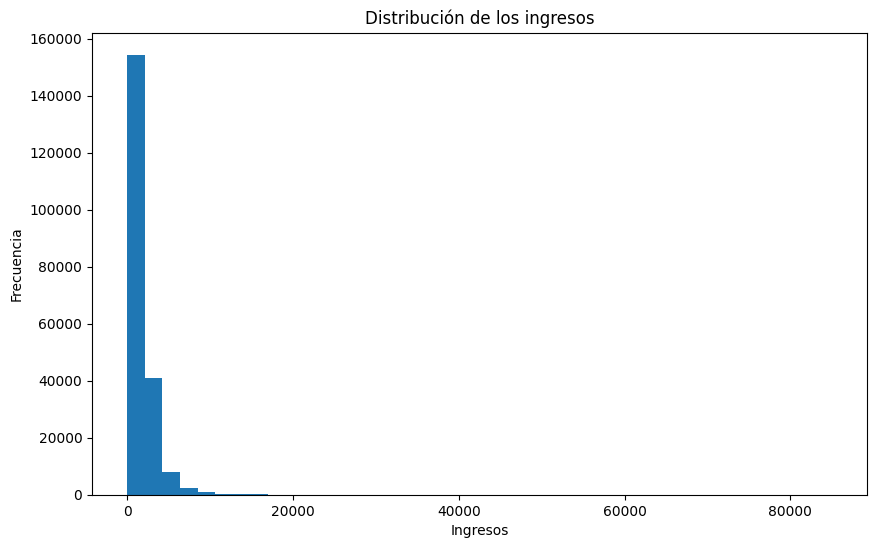

In [24]:
# ============================================================
# EDA 4: DISTRIBUCIÓN DE INGRESOS
# ============================================================

plt.figure(figsize=(10, 6))

plt.hist(
    df["Ingresos"],
    bins=40
)

plt.xlabel("Ingresos")
plt.ylabel("Frecuencia")
plt.title("Distribución de los ingresos")

plt.show()

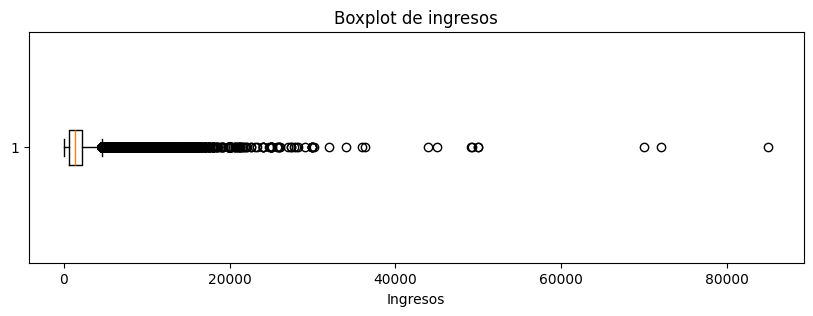

In [25]:
# ============================================================
# EDA 5: OUTLIERS
# ============================================================

plt.figure(figsize=(10, 3))

plt.boxplot(
    df["Ingresos"],
    vert=False
)

plt.xlabel("Ingresos")
plt.title("Boxplot de ingresos")

plt.show()

In [26]:
# ============================================================
# DETECCIÓN DE OUTLIERS MEDIANTE IQR
# ============================================================

Q1 = df["Ingresos"].quantile(0.25)
Q3 = df["Ingresos"].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

print("Límite inferior:", limite_inferior)
print("Límite superior:", limite_superior)

outliers = df[
    (df["Ingresos"] < limite_inferior) |
    (df["Ingresos"] > limite_superior)
]

print("\nNúmero de outliers:", len(outliers))

display(outliers)

Q1: 573.0
Q3: 2165.0
IQR: 1592.0
Límite inferior: -1815.0
Límite superior: 4553.0

Número de outliers: 10087


,Empleo,Sexo,Edad,Etnia,Lengua,Area,Educacion,Ocupacion,Tam_empresa,Horas_Tr,Ingresos
18,Formal,Mujer,63,Mestizo,Castellano,Urbano,Posgrado,Empleado,Grande,50,5977
22,Formal,Hombre,30,Otro,Castellano,Urbano,Universidad,Empleado,Grande,40,5100
75,Formal,Mujer,60,Mestizo,Castellano,Urbano,Universidad,Empleado,Grande,100,7000
77,Formal,Hombre,80,Mestizo,Castellano,Urbano,Secundaria,Empleador,Microempresa,44,6500
79,Formal,Mujer,70,Blanco,Castellano,Urbano,Secundaria,Empleador,Microempresa,60,5000
...,...,...,...,...,...,...,...,...,...,...,...
207180,Formal,Mujer,45,Mestizo,Castellano,Urbano,Universidad,Empleador,Microempresa,56,6000
207209,Formal,Hombre,51,Afrodescendiente,Castellano,Urbano,Universidad,Empleado,Grande,36,5000
207217,Informal,Hombre,33,Quechua,Castellano,Urbano,Posgrado,Empleado,Grande,56,5000
207254,Formal,Hombre,43,Quechua,Quechua,Urbano,Secundaria,Independiente,Microempresa,105,15830


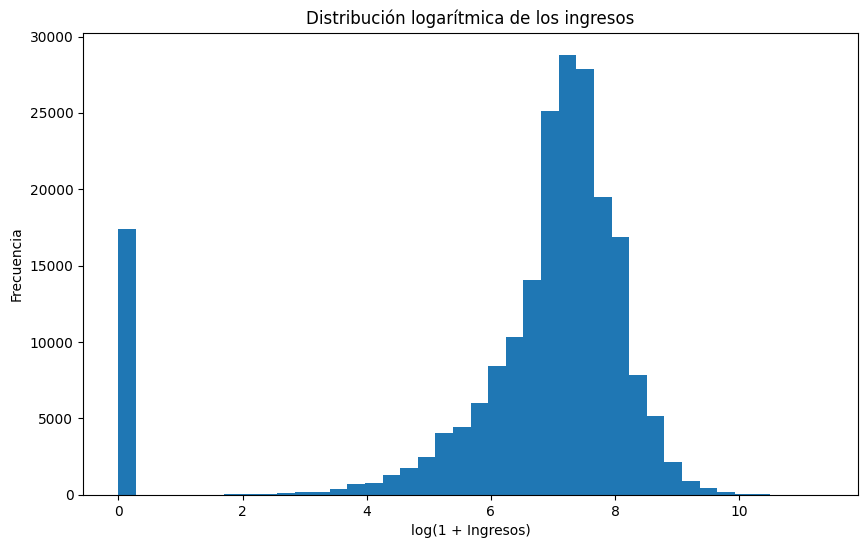

In [27]:
# ============================================================
# EDA 6: INGRESOS EN ESCALA LOGARÍTMICA
# ============================================================

df["Log_Ingresos"] = np.log1p(df["Ingresos"])

plt.figure(figsize=(10, 6))

plt.hist(
    df["Log_Ingresos"],
    bins=40
)

plt.xlabel("log(1 + Ingresos)")
plt.ylabel("Frecuencia")
plt.title("Distribución logarítmica de los ingresos")

plt.show()

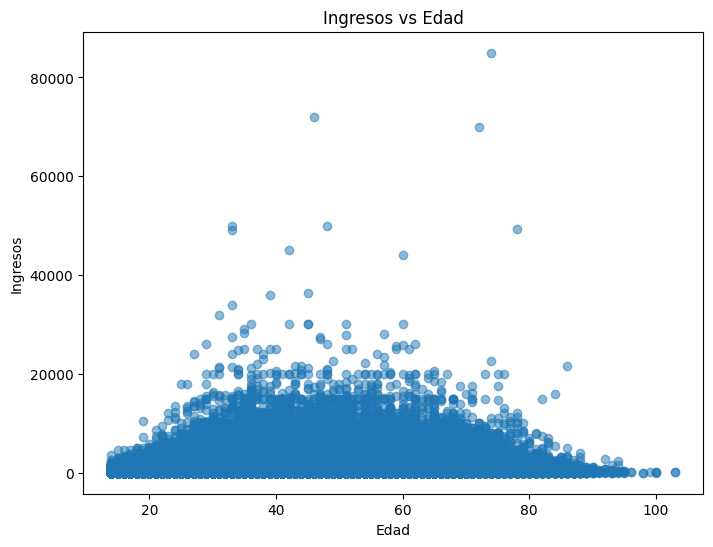

In [28]:
# ============================================================
# EDA 7: INGRESOS VS EDAD
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    df["Edad"],
    df["Ingresos"],
    alpha=0.5
)

plt.xlabel("Edad")
plt.ylabel("Ingresos")
plt.title("Ingresos vs Edad")

plt.show()

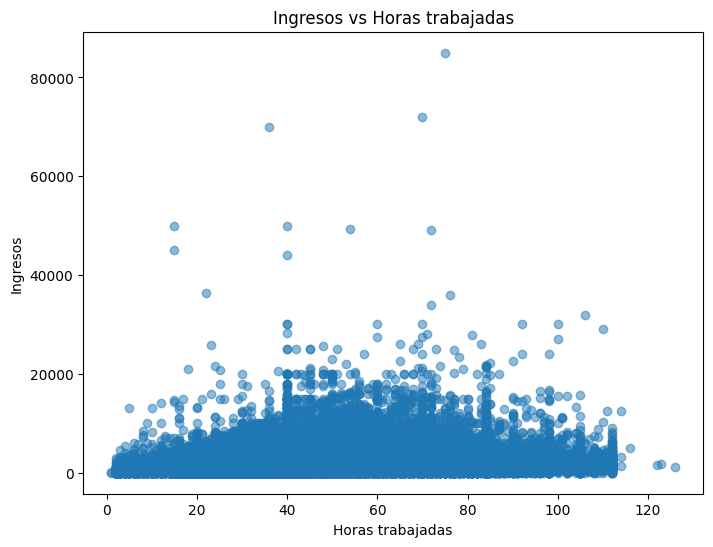

In [29]:
# ============================================================
# INGRESOS VS HORAS TRABAJADAS
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    df["Horas_Tr"],
    df["Ingresos"],
    alpha=0.5
)

plt.xlabel("Horas trabajadas")
plt.ylabel("Ingresos")
plt.title("Ingresos vs Horas trabajadas")

plt.show()

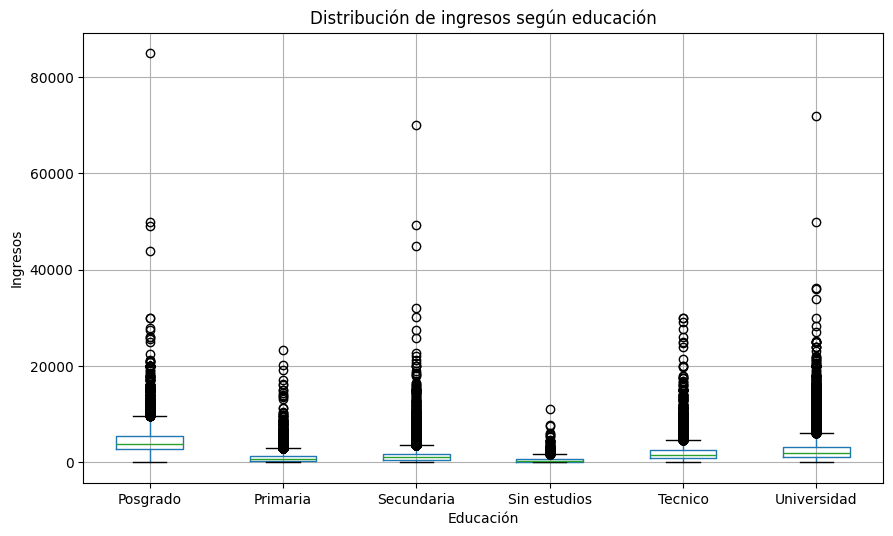

In [30]:
# ============================================================
# EDA 8: INGRESOS SEGÚN EDUCACIÓN
# ============================================================

orden_educacion = [
    "Primaria",
    "Secundaria",
    "Tecnico",
    "Universidad",
    "Posgrado"
]

df.boxplot(
    column="Ingresos",
    by="Educacion",
    figsize=(10, 6)
)

plt.title("Distribución de ingresos según educación")
plt.suptitle("")
plt.xlabel("Educación")
plt.ylabel("Ingresos")

plt.show()

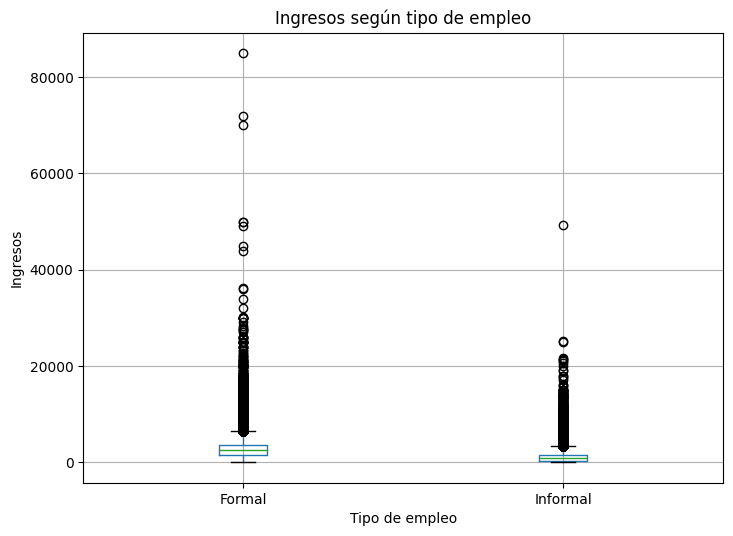

In [31]:
# ============================================================
# INGRESOS SEGÚN TIPO DE EMPLEO
# ============================================================

df.boxplot(
    column="Ingresos",
    by="Empleo",
    figsize=(8, 6)
)

plt.title("Ingresos según tipo de empleo")
plt.suptitle("")
plt.xlabel("Tipo de empleo")
plt.ylabel("Ingresos")

plt.show()

In [36]:
# ==========================================
# 5. TRAIN / TEST
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Transformación logarítmica de la variable objetivo
y_train_log = np.log1p(y_train)

print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (165925, 10)
Datos de prueba: (41482, 10)


In [37]:
# ==========================================
# 6. PREPROCESAMIENTO
# ==========================================

preprocesamiento = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            variables_numericas
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            variables_categoricas
        )
    ]
)

In [38]:
# ==========================================
# 7. MODELOS
# ==========================================

modelos = {

    "Regresión Lineal": LinearRegression(),

    "Ridge": Ridge(alpha=1.0),

    "Lasso": Lasso(alpha=0.1),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

In [39]:
# ==========================================
# 8. ENTRENAMIENTO CON LOGARITMO
# ==========================================

resultados = []

modelos_entrenados = {}

for nombre, modelo in modelos.items():

    pipeline = Pipeline(
        steps=[
            ("preprocesamiento", preprocesamiento),
            ("modelo", modelo)
        ]
    )

    # Entrenamiento usando log(Ingresos)
    pipeline.fit(X_train, y_train_log)

    # Predicción en escala logarítmica
    y_pred_log = pipeline.predict(X_test)

    # Regresar a escala original de ingresos
    y_pred = np.expm1(y_pred_log)

    # Evitar predicciones negativas
    y_pred = np.maximum(y_pred, 0)

    # Métricas en escala original
    mae = mean_absolute_error(y_test, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_test, y_pred)
    )

    r2 = r2_score(y_test, y_pred)

    resultados.append({
        "Modelo": nombre,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

    modelos_entrenados[nombre] = pipeline

In [40]:
# ==========================================
# 9. COMPARACIÓN
# ==========================================

resultados_df = pd.DataFrame(resultados)

resultados_df = resultados_df.sort_values(
    by="RMSE"
)

display(resultados_df)

,Modelo,MAE,RMSE,R2
4,Gradient Boosting,689.859916,1422.965427,0.374170
3,Random Forest,713.840625,1428.790890,0.369035
0,Regresión Lineal,748.846861,1453.999619,0.346574
1,Ridge,748.855782,1454.032529,0.346544
2,Lasso,857.338639,1689.874075,0.117374


In [41]:
# ==========================================
# 10. MEJOR MODELO
# ==========================================

mejor_nombre = resultados_df.iloc[0]["Modelo"]

mejor_modelo = modelos_entrenados[mejor_nombre]

print("Mejor modelo:", mejor_nombre)

Mejor modelo: Gradient Boosting


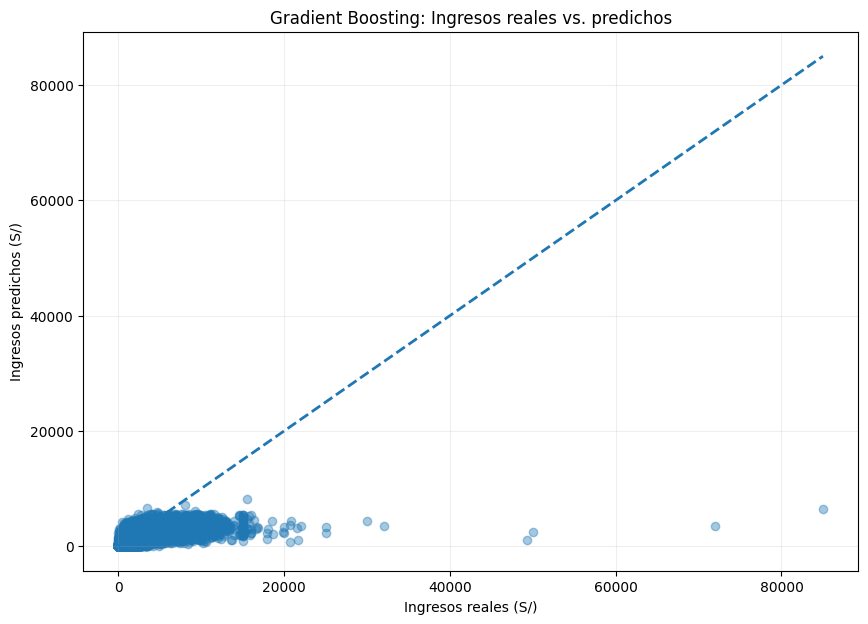

In [43]:
# ==========================================
# 11. REAL VS PREDICHO
# ==========================================

# Predicción en escala logarítmica
y_pred_log = mejor_modelo.predict(X_test)

# Regresar a escala original de ingresos
y_pred = np.expm1(y_pred_log)

# Evitar valores negativos
y_pred = np.maximum(y_pred, 0)

# Crear gráfico
plt.figure(figsize=(10, 7))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.4
)

# Línea ideal: Real = Predicho
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    linewidth=2
)

plt.xlabel("Ingresos reales (S/)")
plt.ylabel("Ingresos predichos (S/)")
plt.title(f"{mejor_nombre}: Ingresos reales vs. predichos")

plt.grid(alpha=0.2)
plt.show()

In [44]:
# ==========================================
# DISTRIBUCIÓN DE INGRESOS
# ==========================================

rangos = pd.cut(
    df["Ingresos"],
    bins=[0, 1000, 2000, 3000, 5000, 10000, 20000, 50000, np.inf],
    labels=[
        "0-1000",
        "1001-2000",
        "2001-3000",
        "3001-5000",
        "5001-10000",
        "10001-20000",
        "20001-50000",
        "Más de 50000"
    ]
)

tabla = (
    rangos
    .value_counts()
    .sort_index()
    .to_frame("Frecuencia")
)

tabla["Porcentaje"] = (
    tabla["Frecuencia"] /
    len(df) * 100
)

display(tabla)

,Frecuencia,Porcentaje
Ingresos,,
0-1000,60924,29.374129
1001-2000,72198,34.809818
2001-3000,29138,14.048706
3001-5000,20412,9.841519
5001-10000,6439,3.104524
10001-20000,858,0.413679
20001-50000,67,0.032304
Más de 50000,3,0.001446


In [45]:
print("Mediana:", df["Ingresos"].median())
print("Media:", df["Ingresos"].mean())

print("\nPercentiles:")
print(
    df["Ingresos"].quantile(
        [0.50, 0.75, 0.90, 0.95, 0.99, 0.995, 0.999]
    )
)

Mediana: 1299.0
Media: 1660.5004459830188

Percentiles:
0.500     1299.0
0.750     2165.0
0.900     3500.0
0.950     4500.0
0.990     8000.0
0.995    10000.0
0.999    15600.0
Name: Ingresos, dtype: float64


In [46]:
# ==========================================
# REVISAR INGRESOS EXTREMOS
# ==========================================

extremos = df.sort_values(
    "Ingresos",
    ascending=False
).head(30)

display(extremos)

,Empleo,Sexo,Edad,Etnia,Lengua,Area,Educacion,Ocupacion,Tam_empresa,Horas_Tr,Ingresos,Log_Ingresos
146146,Formal,Mujer,74,Blanco,Castellano,Urbano,Posgrado,Empleador,Mediana,75,85000,11.350418
146147,Formal,Hombre,46,Blanco,Castellano,Urbano,Universidad,Empleado,Grande,70,72000,11.184435
57054,Formal,Hombre,72,Otro,Castellano,Urbano,Secundaria,Empleador,Grande,36,70000,11.156265
33797,Formal,Hombre,33,Otro,Castellano,Urbano,Universidad,Empleador,Microempresa,15,50000,10.819798
146159,Formal,Hombre,48,Mestizo,Castellano,Urbano,Posgrado,Empleado,Grande,40,50000,10.819798
179831,Informal,Hombre,78,Mestizo,Castellano,Rural,Secundaria,Empleador,Microempresa,54,49269,10.805071
177676,Formal,Hombre,33,Afrodescendiente,Castellano,Urbano,Posgrado,Empleador,Microempresa,72,49067,10.800962
2114,Formal,Hombre,42,Mestizo,Castellano,Urbano,Secundaria,Empleador,Microempresa,15,45000,10.714440
40028,Formal,Mujer,60,Mestizo,Castellano,Urbano,Posgrado,Empleado,Grande,40,43970,10.691286
78391,Formal,Mujer,45,Mestizo,Castellano,Urbano,Universidad,Independiente,Microempresa,22,36300,10.499601


In [47]:
# ==========================================
# 12. TABLA DE PREDICCIONES
# ==========================================

predicciones = pd.DataFrame({
    "Ingreso_real": y_test.values,
    "Ingreso_predicho": y_pred
})

predicciones["Error"] = (
    predicciones["Ingreso_real"]
    - predicciones["Ingreso_predicho"]
)

display(predicciones)

,Ingreso_real,Ingreso_predicho,Error
0,1600,1313.820136,286.179864
1,283,894.308811,-611.308811
2,2165,1670.962949,494.037051
3,0,8.501384,-8.501384
4,3083,3909.594930,-826.594930
...,...,...,...
41477,34,317.252224,-283.252224
41478,1143,30.664547,1112.335453
41479,2100,1350.453986,749.546014
41480,573,883.858053,-310.858053


In [48]:
nuevo_trabajador = pd.DataFrame({
    "Empleo": ["Formal"],
    "Sexo": ["Hombre"],
    "Edad": [35],
    "Etnia": ["Mestizo"],
    "Lengua": ["Castellano"],
    "Area": ["Urbano"],
    "Educacion": ["Universidad"],
    "Ocupacion": ["Empleado"],
    "Tam_empresa": ["Grande"],
    "Horas_Tr": [48]
})


# Predicción en escala logarítmica
ingreso_log = mejor_modelo.predict(
    nuevo_trabajador
)

# Convertir nuevamente a soles
ingreso_predicho = np.expm1(ingreso_log)

print(
    f"Ingreso predicho: S/ {ingreso_predicho[0]:,.2f}"
)

Ingreso predicho: S/ 3,236.42
